## Initializing polymer systems using a DPD potential
This notebook walks through the PhantomWalk functions for packing linear polymers in a box. The polymers are first placed in a cubic box using a random walk. Then a short HOOMD simulation is run with the soft force potential of Dissipative Particle Dynamics. The simulation ends when the pair energy from the DPD potential reaches a stable state, as checked with an autocorrelation function.

In [1]:
import matplotlib
import numpy as np  
import gsd, gsd.hoomd 
import hoomd 
from cmeutils.sampling import is_equilibrated
import time
import freud
import matplotlib_inline
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.style.use("ggplot")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [2]:
def initialize_snapshot_rand_walk(num_pol, num_mon, density=0.85, bond_length=1.0, buffer=0.1):
    '''
    Create a HOOMD snapshot of a cubic box with the given number density.

    
    '''    
    N = num_pol * num_mon
    L = np.cbrt(N / density)  # Calculate box size based on density
    positions = np.zeros((N, 3))
    for i in range(num_pol):
        start = i * num_mon
        positions[start] = np.random.uniform(low=(-L/2),high=(L/2),size=3)
        for j in range(num_mon - 1):
            delta = np.random.uniform(low=(-bond_length/2),high=(bond_length/2),size=3)
            delta /= np.linalg.norm(delta)*bond_length
            positions[start+j+1] = positions[start+j] + delta
    positions = pbc(positions,[L,L,L])
    bonds = []
    for i in range(num_pol):
        start = i * num_mon
        for j in range(num_mon - 1):
            bonds.append([start + j, start + j + 1])
    bonds = np.array(bonds)
    frame = gsd.hoomd.Frame()
    frame.particles.types = ['A']
    frame.particles.N = N
    frame.particles.position = positions
    frame.bonds.N = len(bonds)
    frame.bonds.group = bonds
    frame.bonds.types = ['b']
    frame.configuration.box = [L, L, L, 0, 0, 0]
    return frame

def pbc(d,box):
    for i in range(3):
        a = d[:,i]
        pos_max = np.max(a)
        pos_min = np.min(a)
        while pos_max > box[i]/2 or pos_min < -box[i]/2:
            a[a < -box[i]/2] += box[i]
            a[a >  box[i]/2] -= box[i]
            pos_max = np.max(a)
            pos_min = np.min(a)
    return d

def check_pair_energy(step_cut):
    log = np.genfromtxt("log.txt", names=True)
    pairs = log["mdpairDPDenergy"]
    shrink_cut = step_cut
    equil, t0, g, neff = is_equilibrated(data=pairs[shrink_cut:], threshold_neff=50) 
    if equil:
        return True
    else:
        return False
    
def add_hoomd_writers(sim):
    """Create gsd and log writers."""
    gsd_logger = hoomd.logging.Logger(
        categories=["scalar", "string", "sequence"]
    )
    logger = hoomd.logging.Logger(categories=["scalar", "string"])
    gsd_logger.add(sim, quantities=["timestep", "tps"])
    logger.add(sim, quantities=["timestep", "tps"])
    thermo_props = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
    sim.operations.computes.append(thermo_props)
    log_quantities = [
            "kinetic_temperature",
            "potential_energy",
            "kinetic_energy",
            "volume",
            "pressure",
            "pressure_tensor",
        ]
    gsd_logger.add(thermo_props, quantities=log_quantities)
    logger.add(thermo_props, quantities=log_quantities)

    for f in sim.operations.integrator.forces:
        logger.add(f, quantities=["energy"])
        gsd_logger.add(f, quantities=["energy"])

    gsd_writer = hoomd.write.GSD(
        filename='trajectory.gsd',
        trigger=hoomd.trigger.Periodic(int(10)),
        mode="wb",
        dynamic=["momentum", "property"],
        filter=hoomd.filter.All(),
        logger=gsd_logger,
    )
    gsd_writer.maximum_write_buffer_size = 64 * 1024 * 1024

    table_file = hoomd.write.Table(
        output=open('log.txt', mode="w", newline="\n"),
        trigger=hoomd.trigger.Periodic(period=int(10)),
        logger=logger,
        max_header_len=None,
    )
    sim.operations.writers.append(gsd_writer)
    sim.operations.writers.append(table_file)

def run_nvt_dpd_simulation(A=1000,gamma=1000,k=1000,num_pol=100,num_mon=10,kT=1.0,r_cut = 1.15,bond_l=1.0,dt=0.001,density=0.8,particle_spacing = 1.1
):
    print(num_pol*num_mon)
    print(f"\nRunning with A={A}, gamma={gamma}, k={k}, "
          f"num_pol={num_pol}, num_mon={num_mon}")
    start_time = time.perf_counter()
    frame = initialize_snapshot_rand_walk(num_pol, num_mon, density=density)
    build_stop = time.perf_counter()
    print("Total build time: ", build_stop-start_time)
    harmonic = hoomd.md.bond.Harmonic()
    harmonic.params["b"] = dict(r0=bond_l, k=k)
    integrator = hoomd.md.Integrator(dt=dt)
    integrator.forces.append(harmonic)
    simulation = hoomd.Simulation(device=hoomd.device.auto_select(), seed=np.random.randint(65535))# TODO seed
    simulation.operations.integrator = integrator 
    simulation.create_state_from_snapshot(frame)
    const_vol = hoomd.md.methods.ConstantVolume(filter=hoomd.filter.All())
    integrator.methods.append(const_vol)
    nlist = hoomd.md.nlist.Cell(buffer=0.4)
    simulation.operations.nlist = nlist
    DPD = hoomd.md.pair.DPD(nlist, default_r_cut=r_cut, kT=kT)
    DPD.params[('A', 'A')] = dict(A=A, gamma=gamma)
    integrator.forces.append(DPD)
    add_hoomd_writers(sim=simulation)
    
    simulation.run(0)
    simulation.run(1000)
    for writer in simulation.operations.writers:
        if hasattr(writer, "flush"):
            writer.flush()
    
    snap=simulation.state.get_snapshot()
    shrink_cut = 5
    while not check_pair_energy(shrink_cut): 
        check_time = time.perf_counter()
        if (check_time-start_time) > 60:
            return num_pol*num_mon, 0
        simulation.run(1000)
        for writer in simulation.operations.writers:
            if hasattr(writer, "flush"):
                writer.flush()
        snap=simulation.state.get_snapshot()
        shrink_cut += 50
     
    end_time = time.perf_counter()
    return num_pol*num_mon, end_time - start_time

In [3]:
N,s = run_nvt_dpd_simulation(A=1000,gamma=800,k=20000,num_pol=1,num_mon=5000)
print(f"Finished in time = {s:.2f}s")

5000

Running with A=1000, gamma=800, k=20000, num_pol=1, num_mon=5000
Total build time:  0.029400708008324727
Finished in time = 33.49s


4700


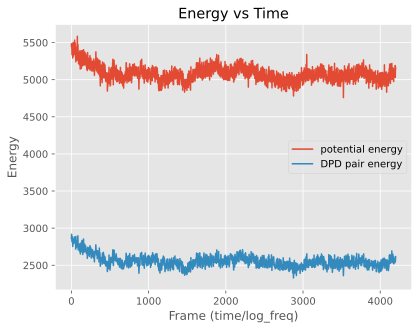

In [4]:
log = np.genfromtxt("log.txt", names=True)
pe = log["mdcomputeThermodynamicQuantitiespotential_energy"]
bonds = log["mdbondHarmonicenergy"]
pairs = log["mdpairDPDenergy"]
print(len(pe))
cut = 500
plt.plot(pe[cut:], label="potential energy")
plt.plot(pairs[cut:], label="DPD pair energy")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()

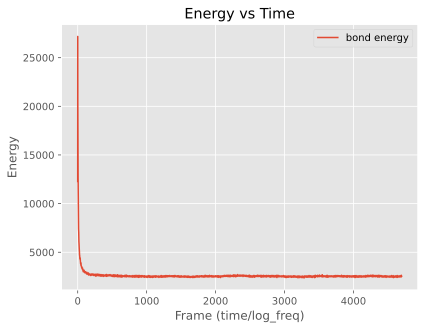

In [7]:
plt.plot(bonds, label="bond energy")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()